# Task 3: Unsupervised Learning

**Objective:** Apply clustering algorithms to group video games based on their attributes (excluding sales) and visualize the clusters in a reduced 2D space.
**Required Inputs:** `../data/cleaned.csv`
**Outputs Produced:** `../data/clustered.csv`

**Feature Selection Justification:**
I am clustering the games based on `year`, `genre`, `console`, and whether they belong to a `top_publisher`. I specifically **excluded** all sales data (`total_sales`, `na_sales`, etc.) from the clustering process. The output of this clustering (the `cluster_label`) will be used as a predictive feature in Task 4. If the clusters were built using sales data, it would cause severe data leakage and artificially inflate the ensemble model's performance.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
CLEAN_DATA_PATH = "../data/cleaned.csv"
CLUSTERED_DATA_PATH = "../data/clustered.csv"

df = pd.read_csv(CLEAN_DATA_PATH)

CURRENT_YEAR = 2026
df['game_age'] = CURRENT_YEAR - df['year']
top_publishers = df['publisher'].value_counts().head(20).index
df['is_top_publisher'] = df['publisher'].isin(top_publishers).astype(int)

features_to_cluster = ['game_age', 'is_top_publisher', 'genre', 'console']
df_cluster = df[features_to_cluster].copy()

df_encoded = pd.get_dummies(df_cluster, columns=['genre', 'console'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

### Determining the Number of Clusters (Elbow Method)
To find the optimal number of clusters, I will use the Elbow Method by calculating the Within-Cluster Sum of Squares (WCSS) for K values from 2 to 10.

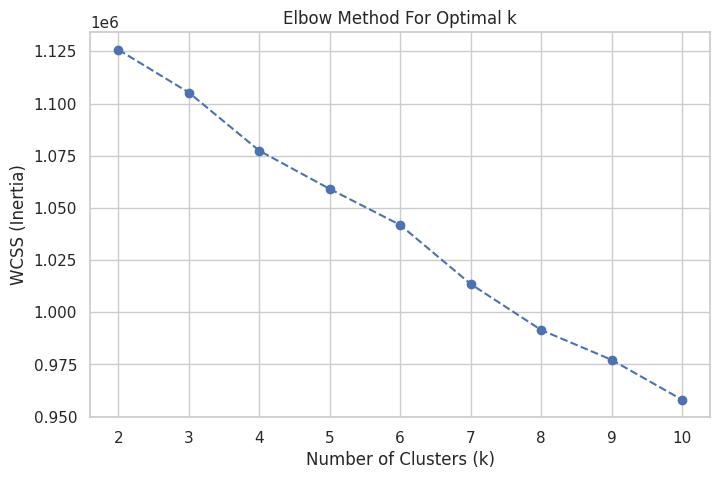

In [ ]:
wcss = []
k_range = range(2,11)
sample_size = min(20000, X_scaled.shape[0])

np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=sample_size, replace=False)
X_sample = X_scaled[sample_indices]

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)

os.makedirs('diagrams', exist_ok=True)
plt.savefig("../diagrams/Elbow_Method_For_Optimal_k.png")

plt.show()


**Elbow Method Interpretation:**
The curve doesn't show a perfectly sharp elbow, which is common with highly categorical/one-hot encoded data. However, the curve starts to flatten out more noticeably after **k=4**. I will proceed with 4 clusters to keep the segmentation interpretable and meaningful.

### Applying Clustering Algorithms
I will apply **K-Means** (a centroid-based algorithm) and **Gaussian Mixture Model (GMM)** (a probabilistic distribution-based algorithm). We will use K-Means for the final assignment as it scales well and provides solid baseline groupings.

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X_scaled)
# Why random state 42? What is GMM?
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_sample)

print("Clustering complete. K-Means assigned to 'cluster_label'.")

Clustering complete. K-Means assigned to 'cluster_label'.


### Dimensionality Reduction and Visualization
To visualize the 4 clusters, I will use **Principal Component Analysis (PCA)** to reduce the high-dimensional one-hot encoded feature space down to 2 dimensions.

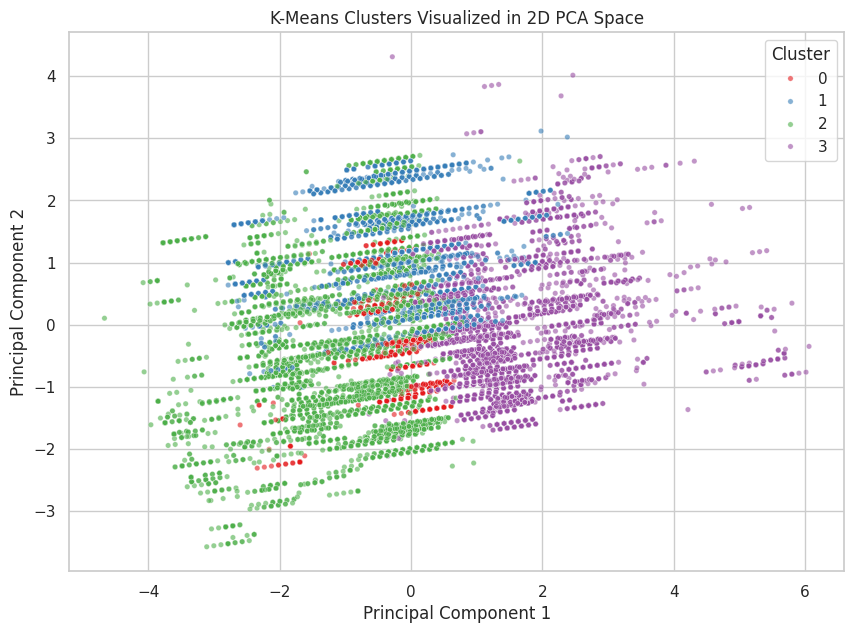

In [19]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='cluster_label',
    palette='Set1',
    data=df,
    alpha=0.6,
    s=15
)
plt.title('K-Means Clusters Visualized in 2D PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.savefig("../diagrams/K-Means Clusters Visualized in 2D PCA Space.png")
plt.show()

### Cluster Interpretation
Let's analyze the statistical properties of each cluster to give them human-readable labels.

In [14]:
cluster_summary = df.groupby('cluster_label').agg({
    'year': 'mean',
    'genre': lambda x: x.mode()[0],
    'console': lambda x: x.mode()[0],
    'publisher': lambda x: x.mode()[0],
    'is_top_publisher': 'mean'
}).round(2)

display(cluster_summary)

df_to_save = df.drop(columns=['PCA1', 'PCA2', 'game_age', 'is_top_publisher'])
df_to_save.to_csv(CLUSTERED_DATA_PATH, index=False)
print(f"\nClustered dataset exported to {CLUSTERED_DATA_PATH}")

,year,genre,console,publisher,is_top_publisher
cluster_label,,,,,
0,2009.15,Misc,Wii,Activision,0.54
1,2008.68,Adventure,PC,Electronic Arts,0.36
2,2011.47,Action,DS,Ubisoft,0.51
3,2001.58,Sports,PS2,Konami,0.56



Clustered dataset exported to ../data/clustered.csv
